# Deutsch's Algorithm

[Deutsch's algorithm on IBM Quantum](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-algorithm)

In [1]:
# Random.
import random

# Combinatorics.
import itertools as it

# Quantum computing.
import qiskit

# Quantum simulator.
import qiskit_aer as aer

# Quantum visualization.
import qiskit.visualization as viz

# Quantum information.
import qiskit.quantum_info as info

## XOR

| $x$ | $y$ | $x \oplus y$ |
|:---:|:---:|:---:|
| $0$ | $0$ | $0$ |
| $0$ | $1$ | $1$ |
| $1$ | $0$ | $1$ |
| $1$ | $1$ | $0$ |

In [2]:
# Xor table.
print('x y ⊕')
for x, y in it.product((0, 1), repeat=2):
    print(f'{x} {y} {x^y}')

x y ⊕
0 0 0
0 1 1
1 0 1
1 1 0


In [3]:
def colvec(qc):
  """Helper function to draw column vectors nicely."""
  # https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.visualization.array_to_latex
  # https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.quantum_info.Statevector#from_instruction
  return viz.array_to_latex(info.Statevector.from_instruction(qc).data.reshape(-1, 1))

## State Vectors

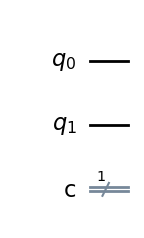

In [4]:
# Two qubits, one classical bit.
qc = qiskit.QuantumCircuit(2, 1)

# Show.
qc.draw(output="mpl")

In [5]:
# State vector at end of qc.
colvec(qc)

<IPython.core.display.Latex object>

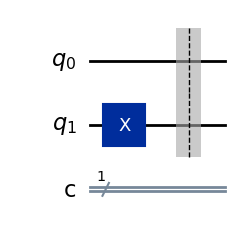

In [6]:
# Quickest way to set qubit 2 to |1>.
qc.x(1)

# Barrier.
qc.barrier()

# Draw.
qc.draw(output='mpl')

In [7]:
# State vector at end of qc.
colvec(qc)

<IPython.core.display.Latex object>

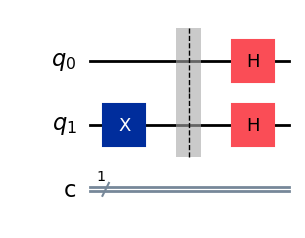

In [8]:
# H gates.
qc.h((0, 1))

# Show.
qc.draw(output="mpl")

In [9]:
# State vector.
colvec(qc)

<IPython.core.display.Latex object>

## By Hand

### Initial State Vector

$
  \begin{bmatrix} 1 \\ 0 \end{bmatrix} \otimes \begin{bmatrix} 0 \\ 1 \end{bmatrix} = \begin{bmatrix} 0 \\ 1 \\ 0 \\ 0 \end{bmatrix}
$

### $H$ Gates

$
  H \otimes H = \frac{1}{\sqrt{2}} \begin{bmatrix} 1 & 1 \\ 1 & -1 \end{bmatrix} \otimes \frac{1}{\sqrt{2}} \begin{bmatrix} 1 & 1 \\ 1 & -1 \end{bmatrix}
              = \frac{1}{2} \begin{bmatrix} 1 & 1 & 1 & 1 \\ 1 & -1 & 1 & -1 \\ 1 & 1 & -1 & -1 \\ 1 & -1 & -1 & 1 \end{bmatrix}
$

### Circuit

$
\frac{1}{2} \begin{bmatrix} 1 & 1 & 1 & 1 \\ 1 & -1 & 1 & -1 \\ 1 & 1 & -1 & -1 \\ 1 & -1 & -1 & 1 \end{bmatrix} \begin{bmatrix} 0 \\ 1 \\ 0 \\ 0 \end{bmatrix} = \frac{1}{2} \begin{bmatrix} 1 \\ -1 \\ 1 \\ -1 \end{bmatrix}
$

## Why the Difference to Qiskit?

### Qiskit is Big-Endian(ish)

$
  \begin{bmatrix} 0 \\ 1 \end{bmatrix} \otimes \begin{bmatrix} 1 \\ 0 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \\ 1 \\ 0 \end{bmatrix}
$

$
\frac{1}{2} \begin{bmatrix} 1 & 1 & 1 & 1 \\ 1 & -1 & 1 & -1 \\ 1 & 1 & -1 & -1 \\ 1 & -1 & -1 & 1 \end{bmatrix} \begin{bmatrix} 0 \\ 0 \\ 1 \\ 0 \end{bmatrix} = \frac{1}{2} \begin{bmatrix} 1 \\ 1 \\ -1 \\ -1 \end{bmatrix}
$

## Identity Function

$f(0) = 0 \qquad f(1) = 1$

| $x$ | $y$ |  | $f(x)$ | $y \oplus f(x)$ |
|:---:|:---:|:---:|:---:|:---:|
|  0  |  0  |  $\rightarrow$ | 0 | 0 |
|  0  |  1  |  $\rightarrow$ | 0 | 1 |
|  1  |  0  |  $\rightarrow$ | 1 | 1 |
|  1  |  1  |  $\rightarrow$ | 1 | 0 |

$\ket{00} \rightarrow \ket{00}$  
$\ket{01} \rightarrow \ket{01}$  
$\ket{10} \rightarrow \ket{11}$  
$\ket{11} \rightarrow \ket{10}$


$U \begin{bmatrix} a \\ b \\ c \\ d \end{bmatrix} = \begin{bmatrix} a \\ b \\ d \\ c \end{bmatrix}$

$r_0 \begin{bmatrix} a \\ b \\ c \\ d \end{bmatrix} = a \Rightarrow r_0 = \begin{bmatrix} 1 & 0 & 0 & 0 \end{bmatrix}$

$U = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \end{bmatrix} = CX$

### Circuit

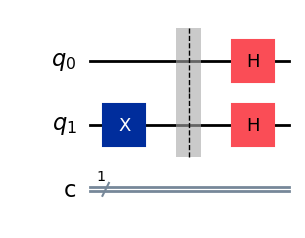

In [10]:
# Two qubits, one classical.
start = qiskit.QuantumCircuit(2, 1)

# Quickest way to set qubit 2 to |1>.
start.x(1)

# Barrier.
start.barrier()

# H Gates.
start.h((0, 1))

# Show.
start.draw(output='mpl')

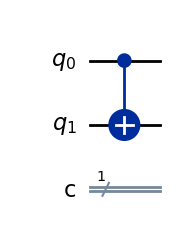

In [11]:
# Two qubits, one classical.
oracle = qiskit.QuantumCircuit(2, 1)

# CX.
oracle.cx(0, 1)

# Show.
oracle.draw(output='mpl')

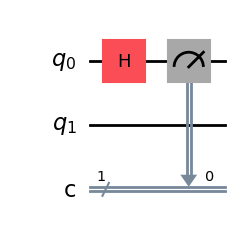

In [12]:
# Two qubits, one classical.
end = qiskit.QuantumCircuit(2, 1)

# H Gate.
end.h(0)

# Measure.
end.measure(0, 0)

# Show.
end.draw(output='mpl')

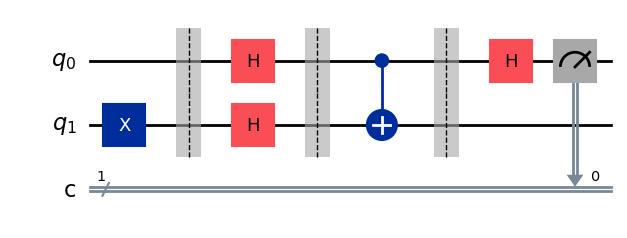

In [13]:
# Two qubits, one classical.
qc = qiskit.QuantumCircuit(2, 1)

# Compose.
qc.compose(start, inplace=True)
qc.barrier()
qc.compose(oracle, inplace=True)
qc.barrier()
qc.compose(end, inplace=True)

# Show.
qc.draw(output='mpl')

## Oracles

| $x$ | $f_0$ | $f_1$ | $f_2$ | $f_3$ |
|:---:|:-----:|:-----:|:-----:|:-----:|
|  0  |   0   |   0   |   1   |   1   |
|  1  |   0   |   1   |   0   |   1   |

![Deutsch's Algorithm Circuit WikiPedia](https://upload.wikimedia.org/wikipedia/commons/thumb/8/8a/Deutsch_algorithm_circuit.svg/960px-Deutsch_algorithm_circuit.svg.png)

### $f_1$

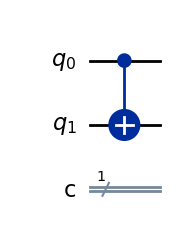

In [14]:
# Two qubits, one classical.
f1 = qiskit.QuantumCircuit(2, 1)

# CX.
f1.cx(0, 1)

# Show.
f1.draw(output='mpl')

### $f_0$

| $x$ | $y$ | $f(x)$ | $y \oplus f(x)$ |
|:---:|:---:|:------:|:---------------:|
|  0  |  0  |    0   |       0         |
|  0  |  1  |    0   |       1         |
|  1  |  0  |    0   |       0         |
|  1  |  1  |    0   |       1         |

$\ket{00} \rightarrow \ket{00}$  
$\ket{01} \rightarrow \ket{01}$  
$\ket{10} \rightarrow \ket{10}$  
$\ket{11} \rightarrow \ket{11}$

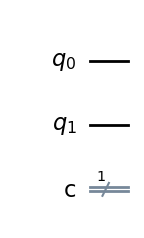

In [15]:
# Two qubits, one classical.
f0 = qiskit.QuantumCircuit(2, 1)

# Show.
f0.draw(output='mpl')

### $f_2$

| $x$ | $y$ | $f(x)$ | $y \oplus f(x)$ |
|:---:|:---:|:------:|:---------------:|
|  0  |  0  |    1   |       1         |
|  0  |  1  |    1   |       0         |
|  1  |  0  |    0   |       0         |
|  1  |  1  |    0   |       1         |

$\ket{00} \rightarrow \ket{01}$  
$\ket{01} \rightarrow \ket{00}$  
$\ket{10} \rightarrow \ket{10}$  
$\ket{11} \rightarrow \ket{11}$

$U_{f_2} = \begin{bmatrix} 0 & 1 & 0 & 0 \\ 1 & 0 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}$

$U_{f_2} = (I \otimes X) CX = \begin{bmatrix} 0 & 1 & 0 & 0 \\ 1 & 0 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \end{bmatrix} \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \end{bmatrix} = \begin{bmatrix} 0 & 1 & 0 & 0 \\ 1 & 0 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \end{bmatrix}$

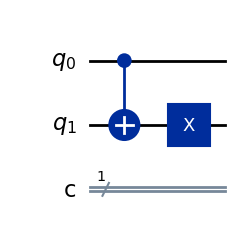

In [16]:
# Two qubits, one classical.
f2 = qiskit.QuantumCircuit(2, 1)

# CX.
f2.cx(0, 1)

# X.
f2.x(1)

# Show.
f2.draw(output='mpl')

### $f_3$

| $x$ | $y$ | $f(x)$ | $y \oplus f(x)$ |
|:---:|:---:|:------:|:---------------:|
|  0  |  0  |    1   |       1         |
|  0  |  1  |    1   |       0         |
|  1  |  0  |    1   |       1         |
|  1  |  1  |    1   |       0         |

$\ket{00} \rightarrow \ket{01}$  
$\ket{01} \rightarrow \ket{00}$  
$\ket{10} \rightarrow \ket{11}$  
$\ket{11} \rightarrow \ket{10}$

$U_{f_3} = \begin{bmatrix} 0 & 1 & 0 & 0 \\ 1 & 0 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \end{bmatrix} = I \otimes X$

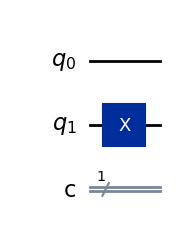

In [17]:
# Two qubits, one classical.
f3 = qiskit.QuantumCircuit(2, 1)

# X.
f3.x(1)

# Show.
f3.draw(output='mpl')

## Run the Circuit

In [18]:
def run_circuit(oracle):
  """Simulate Deutsch's algorithm using oracle."""
  # Initial part of circuit.
  start = qiskit.QuantumCircuit(2, 1)
  # Quickest way to set qubit 2 to |1>.
  start.x(1)
  # H Gates.
  start.h((0, 1))

  # End part of circuit.
  end = qiskit.QuantumCircuit(2, 1)
  # H Gate.
  end.h(0)
  # Measure.
  end.measure(0, 0)

  # Compose the start, oracle, and end circuits.
  qc = qiskit.QuantumCircuit(2, 1)
  qc.compose(start, inplace=True)
  qc.compose(oracle, inplace=True)
  qc.compose(end, inplace=True)

  # Initialize the simulator.
  simulator = aer.AerSimulator()
  # Compile our quantum circuit for the simulator.
  compiled = qiskit.transpile(qc, simulator)
  # Run the circuit.
  result = simulator.run(compiled, shots=1024).result()

  # Return the results.
  return result.get_counts()

In [19]:
# Oracles.
oracles = [f0, f1, f2, f3]

# Show.
oracles

In [20]:
# Test oracle.
[run_circuit(oracle) for oracle in oracles]

[{'0': 1024}, {'1': 1024}, {'1': 1024}, {'0': 1024}]

In [21]:
# Select an oracle at random.
run_circuit(random.choice(oracles))

{'1': 1024}

## End